# E2

Quadrants are back! You need to divide the messi.jpg image into four different quadrants. The following modifications must be applied:


1. Q0: Nothing, plain grayscale.
2. Q1: High-pass filter result.
3. Q2: Low-pass filter result.
4. Q3: Canny edges of the quadrant.

The resulting image should look like this:

![](./E2_result.png)


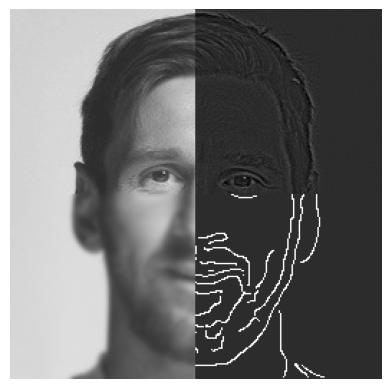

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, feature, img_as_float 
from skimage.filters import gaussian

from scipy.ndimage import gaussian_filter

# === Load and prepare image ===
img = io.imread('messi.jpg')
width = img.shape[0]
height = img.shape[1]
img_grayscale = color.rgb2gray(img)
low_filter = gaussian(img_grayscale, sigma=1.5)
high_filter = img_grayscale - low_filter
canny_filter = feature.canny(low_filter)

final_image = np.zeros((258,259))
final_image[:width//2, : height//2] = img_grayscale[:width//2, : height//2]
final_image[width//2:, : height//2] = low_filter[height//2:, :width//2]
final_image[width//2:, height//2:] = canny_filter[width//2:, height//2:]
final_image[:width//2, height//2:] = high_filter[:width//2, height//2:]

plt.axis('off')
plt.imshow(final_image, cmap ='gray')